# K-Nearest Neighbors on Personal Transaction Data

Brianna Sengchan

## Imports & Data Loading

In [21]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

In [4]:
sys.path.insert(0, "../data")

from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)
print("number of features:", len(feature_cols))
print("number of classes:", y_train.nunique())

train: (8644, 60) (8644,)
test:  (2162, 60) (2162,)
number of features: 60
number of classes: 22


## Model Training & Evaluation

In [22]:
X_train

,Transaction Type,Day of Week,Month,Amount_scaled,Desc_Amazon,Desc_Amazon Video,Desc_American Tavern,Desc_BBQ Restaurant,Desc_BP,Desc_Bakery Place,...,Desc_State Farm,Desc_Sushi Restaurant,Desc_Target,Desc_Thai Restaurant,Desc_Valero,Desc_Vietnamese Restaurant,Desc_Wendy's,Acct_Checking,Acct_Platinum Card,Acct_Silver Card
6983,1,1,5,0.366366,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
10759,0,5,11,-0.293635,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6149,0,6,6,0.209318,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5548,0,4,9,0.095156,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5127,1,3,7,-0.293380,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594,1,0,4,0.061919,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3800,0,5,12,-0.497144,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
7085,0,5,12,-0.175440,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6761,1,5,10,-0.126069,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [23]:
# Checking the class distribution for data imbalance

class_distribution = y_train.value_counts()

print("Class distribution in training set:")
print(class_distribution)

print("\nClass distribution percentage:")
print((class_distribution / len(y_train) * 100).round(2))

Class distribution in training set:
Category_label
3     1425
9     1157
18     950
19     687
21     675
8      517
17     509
11     353
2      345
1      306
12     264
0      221
13     197
14     197
15     185
10     178
16     155
6      142
4       84
20      65
7       18
5       14
Name: count, dtype: int64

Class distribution percentage:
Category_label
3     16.49
9     13.39
18    10.99
19     7.95
21     7.81
8      5.98
17     5.89
11     4.08
2      3.99
1      3.54
12     3.05
0      2.56
13     2.28
14     2.28
15     2.14
10     2.06
16     1.79
6      1.64
4      0.97
20     0.75
7      0.21
5      0.16
Name: count, dtype: float64


### Baseline Model

In [24]:
# KNN model
knn = KNeighborsClassifier(
    n_neighbors = 5,
    weights = "uniform",
    metric = "minkowski",
    p=2
)

start_train = time.time()
knn.fit(X_train, y_train)
baseline_train_time = time.time() - start_train

start_pred = time.time()
baseline_pred = knn.predict(X_test)
baseline_pred_time = time.time() - start_pred

# Print Results
print("Accuracy: ", accuracy_score(y_test, baseline_pred))
print("Weighted F1: ", f1_score(y_test, baseline_pred, average = "weighted", zero_division = 0))
print("Training Time: ", baseline_train_time)
print("Prediction TIme: ", baseline_pred_time)

Accuracy:  0.1267345050878816
Weighted F1:  0.1144903060477041
Training Time:  0.005135059356689453
Prediction TIme:  0.02076411247253418


### Hyperparameter Tuning

In [25]:
param_grid = {
    "n_neighbors": [3, 5, 7, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn = KNeighborsClassifier(
    metric = "minkowski",
    algorithm = "brute"
)

grid = GridSearchCV(
    estimator = knn,
    param_grid = param_grid,
    scoring = "f1_weighted",
    cv = 2,
    n_jobs = -1,
    verbose = 1
)

start_train = time.time()
grid.fit(X_train, y_train)
tuned_time = time.time() - start_train

# Print Results
print("Best Parameters: ", grid.best_params_)
print("Best Weighted F1: ", grid.best_score_)
print("Tuned Time: ", tuned_time)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best Parameters:  {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Best Weighted F1:  0.11700000261129195
Tuned Time:  5.1550374031066895


### Evaluation

In [26]:
best_knn = grid.best_estimator_

start_pred = time.time()
tuned_pred = best_knn.predict(X_test)
tuned_pred_time = time.time() - start_pred

accuracy = accuracy_score(y_test, tuned_pred)
precision = precision_score(y_test, tuned_pred, average = "weighted", zero_division = 0)
recall = recall_score(y_test, tuned_pred, average = "weighted", zero_division = 0)
f1 = f1_score(y_test, tuned_pred, average = "weighted", zero_division = 0)

print("Best Parameters: ", grid.best_params_)
print("Accuracy: ", accuracy)
print("Weighted Precision: ", precision)
print("Weighted Recall: ", recall)
print("Weighted F1: ", f1)
print("Prediction Time: ", tuned_pred_time)

Best Parameters:  {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Accuracy:  0.1276595744680851
Weighted Precision:  0.11360499586742252
Weighted Recall:  0.1276595744680851
Weighted F1:  0.11785573738141002
Prediction Time:  0.06068158149719238


### Classification Report

In [30]:
print("Final Tuned KNN Classification Report")
print("------------------------------------")
print(classification_report(y_test, tuned_pred, zero_division = 0))

Final Tuned KNN Classification Report
------------------------------------
              precision    recall  f1-score   support

           0       0.05      0.04      0.04        55
           1       0.00      0.00      0.00        77
           2       0.12      0.07      0.09        86
           3       0.21      0.29      0.24       356
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00         4
           6       0.04      0.03      0.03        35
           7       0.00      0.00      0.00         5
           8       0.06      0.06      0.06       130
           9       0.16      0.21      0.18       289
          10       0.05      0.02      0.03        44
          11       0.07      0.05      0.05        88
          12       0.07      0.05      0.05        66
          13       0.03      0.02      0.02        49
          14       0.09      0.08      0.09        49
          15       0.10      0.04      0.06        46
      

### Per-Class Accuracy

In [27]:
# Checking Per-Class Accuracy

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, tuned_pred, labels = labels)

class_accuracy = cm.diagonal() / cm.sum(axis = 1)

class_accuracy_df = pd.DataFrame({
    "Class": labels,
    "Accuracy": class_accuracy
})

class_accuracy_df

,Class,Accuracy
0,0,0.036364
1,1,0.000000
2,2,0.069767
3,3,0.292135
4,4,0.000000
5,5,0.000000
6,6,0.028571
7,7,0.000000
8,8,0.061538
9,9,0.214533


### Confusion Matrix

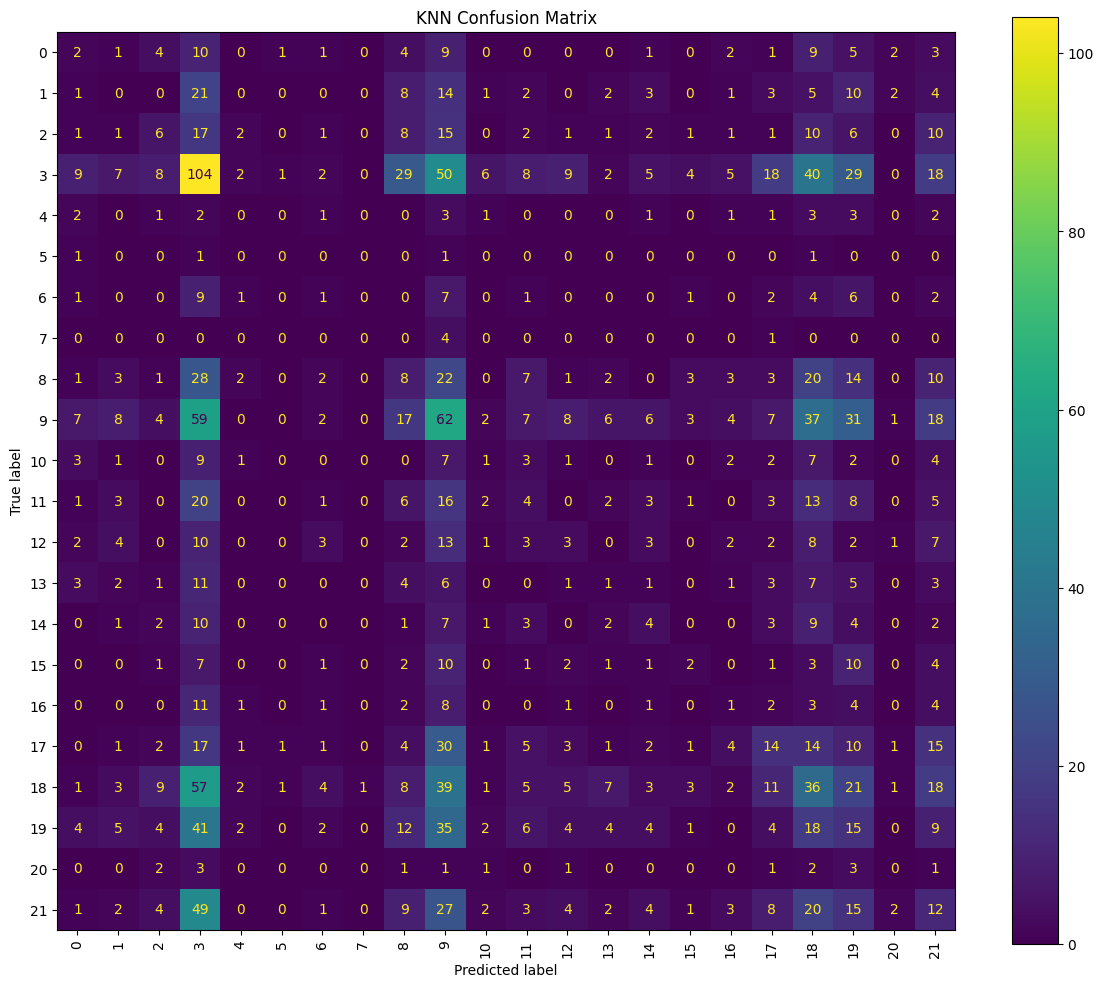

In [28]:
fig, ax = plt.subplots(figsize = (12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = labels
)

display.plot(
    ax = ax,
    xticks_rotation = 90,
    values_format = "d"
)

plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()